# ER thresholds: Markovian vs heavy-tailed recovery

Summary of empirical SIS thresholds on an Erdős–Rényi (ER) network for different recovery regimes, compared to the spectral prediction $1/\lambda_{\max}$.

Assumes you have run:
- `python scripts/run_pipeline.py --all` (which runs `01-export-networks`, `05-baseline-empirical-threshold-ER`, `06-baseline-ER-power-law-Tang`, `07-baseline-ER-lognormal-Tang`),
- and then `sis_threshold_analysis.ipynb` to produce `output/empirical_thresholds.csv` and `output/threshold_ratio_by_run.csv`.


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def _project_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "NetLogo" / "virus_simulation.nlogox").is_file():
            return p
    raise FileNotFoundError(
        "Could not find NetLogo/virus_simulation.nlogox. Open the repo root in Cursor (File → Open Folder)."
    )


ROOT = _project_root()
OUT = ROOT / "output"
LAMBDA_PATH = OUT / "lambda_max.csv"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7, 4.5)
ROOT

WindowsPath('C:/Dossiers/Master AI/Research Methods for AI (IM1312)/RMAI Research Project')

In [2]:
# Load spectral data and empirical thresholds
lam = pd.read_csv(LAMBDA_PATH)
lam["net_label"] = lam["net_label"].astype(str)

er_row = lam.query("net_label == 'ER'").iloc[0]
lambda_max_er = float(er_row["lambda_max"])
print(f"lambda_max (ER) = {lambda_max_er:.6f}")

emp_path = OUT / "empirical_thresholds.csv"
if not emp_path.is_file():
    raise FileNotFoundError(
        f"Missing {emp_path}. Run sis_threshold_analysis.ipynb up to the cell that writes empirical_thresholds.csv."
    )

emp = pd.read_csv(emp_path)
# For the ER baselines, recovery_regime encodes the experiment table name;
# net_label is NA, so we do not filter on net_label here.
emp.head()

lambda_max (ER) = 7.180628


,recovery_regime,net_label,random_seed,beta_pred,beta_hat_surv_50,beta_hat_surv_25,beta_hat_surv_50_median_boot,beta_hat_surv_50_ci_low,beta_hat_surv_50_ci_high,beta_hat_logit_ed50_surv,beta_hat_persist_50,beta_hat_persist_relaxed_50,median_tick_if_extinct,median_tick_if_survive,ratio_surv_50_over_pred,beta_hat_50_legacy_persist,ratio_legacy_over_pred
0,exponential,ER,10001,0.027853,0.048,0.048,0.048,0.048,0.048,NaN,0.048,0.048,8.0,NaN,1.723351,0.048,1.723351
1,lognormal (Tang),ER,10001,0.027853,0.048,0.048,0.048,0.048,0.048,NaN,0.048,0.048,9.0,NaN,1.723351,0.048,1.723351
2,power law (Tang),ER,10001,0.027853,0.044,0.044,0.044,0.044,0.044,NaN,0.048,0.048,15.0,10000.0,1.579738,0.048,1.723351


In [3]:
# Focus on ER baseline experiments and compute tau-based thresholds
# Here recovery_regime contains the table/experiment name, e.g. "05-baseline-empirical-threshold-ER_table"
# We keep all distinct regimes present in the file.
er_emp = emp.copy()

# recovery_mean is fixed at 5 in the baseline experiments
E_W = 5.0
_tau_pred = 1.0 / lambda_max_er  # spectral prediction in tau = beta * E[W]

# beta_pred may be NaN for these baseline tables; we recompute tau_pred from lambda_max
er_emp["tau_hat_surv_50"] = er_emp["beta_hat_surv_50"] * E_W
er_emp["tau_pred"] = _tau_pred
er_emp["ratio_tau_over_pred"] = er_emp["tau_hat_surv_50"] / _tau_pred

er_emp[[
    "recovery_regime",
    "beta_hat_surv_50",
    "tau_hat_surv_50",
    "beta_pred",
    "tau_pred",
    "ratio_surv_50_over_pred",
    "ratio_tau_over_pred",
]]

,recovery_regime,beta_hat_surv_50,tau_hat_surv_50,beta_pred,tau_pred,ratio_surv_50_over_pred,ratio_tau_over_pred
0,exponential,0.048,0.24,0.027853,0.139264,1.723351,1.723351
1,lognormal (Tang),0.048,0.24,0.027853,0.139264,1.723351,1.723351
2,power law (Tang),0.044,0.22,0.027853,0.139264,1.579738,1.579738


C:\Users\janru\AppData\Local\Temp\ipykernel_40360\480401503.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="recovery_regime")


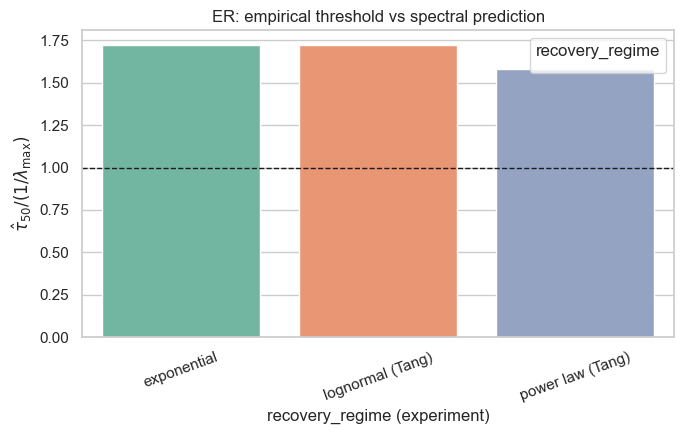

In [4]:
# Bar plot: empirical vs spectral threshold (tau) for ER
# Use different colors per recovery_regime for visual separation.
fig, ax = plt.subplots()
palette = sns.color_palette("Set2", n_colors=er_emp["recovery_regime"].nunique())
sns.barplot(
    data=er_emp,
    x="recovery_regime",
    y="ratio_tau_over_pred",
    hue="recovery_regime",
    dodge=False,
    palette=palette,
    ax=ax,
)
ax.axhline(1.0, color="k", linestyle="--", linewidth=1)
ax.set_ylabel(r"$\hat{\tau}_{50} / (1/\lambda_{\max})$")
ax.set_xlabel("recovery_regime (experiment)")
ax.set_title("ER: empirical threshold vs spectral prediction")
ax.legend(title="recovery_regime")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
